# Model Serialization Formats: pickle, joblib, and ONNX

A trained Python model is just an in-memory object. To deploy it you must serialize it to a file that can be sent to a server, stored in an artifact registry, or shipped to an edge device. This notebook compares three formats: pickle, joblib, and ONNX.

**Learning objectives**
1. Explain what serialization is and why it is required for deployment.
2. Save and reload a model with both pickle and joblib, and verify predictions are preserved.
3. Understand the ONNX format and run inference with onnxruntime.
4. Choose the right format based on portability and environment requirements.

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 5, lesson 03 "ONNX Model Conversion for Cross-Platform Deployment" — ONNX export and ONNX Runtime were taught there for a PyTorch model; here that same format is put head to head against pickle and joblib for an sklearn pipeline, so the choice becomes a decision rather than a default.


## 📰 Why Hugging Face scans every pickle you upload

Hugging Face — the largest public store of trained models — runs a security scan on **every** file pushed to the Hub, and one of the two scans exists purely because of the format this notebook starts with. Their published security documentation states the problem plainly: unpickling *executes code*. A pickle file is a stack of opcodes, and three of them (`GLOBAL`, `STACK_GLOBAL`, `REDUCE`) tell the unpickler to import something and call it. That is enough to run `exec` on an arbitrary string hidden inside what looks like a model file. So the Hub runs ClamAV plus a dedicated **pickle-import scan** that reads the opcodes *without* executing them and shows you, next to the file, exactly what a `torch.load` would import. The same concern is why Hugging Face created the `safetensors` format, and why scikit-learn's own persistence docs now point users towards `skops` for untrusted artifacts.

**The same property, one layer down.** Between **25 and 30 December 2022**, a malicious package named `torchtriton` on PyPI shadowed the one PyTorch publishes on its own index; anyone installing PyTorch-nightly on Linux in that window got a binary that read `~/.ssh/`, `/etc/passwd` and the first 1,000 files of their home directory and exfiltrated them over DNS. *Installing* runs code and *unpickling* runs code — the two most routine actions in an ML workflow are both execution. Unit 4 notebook 01 returns to this when we pin a Dockerfile.

**What goes wrong without this lesson.** "Serialize the model" sounds like a filing decision — pick a format, move on. It is actually three decisions with different failure modes: *can the receiving machine read it* (portability), *will it still load next year* (version coupling), and *what happens if the file came from someone you do not know* (execution). Choose by habit and you find out which one bit you only in production: a mobile team that cannot install Python, an `AttributeError` after a library upgrade, or a model file that ran a shell command when your server loaded it.

## 1  What is serialization?

Serialization converts a live Python object into bytes that can be written to disk or sent over a network. Without it, your model disappears when the Python process ends. The receiving system deserializes the bytes back into an object and calls `.predict()` as if nothing happened — as long as it understands the same format.


## 2  Train a classifier

We train one RandomForest on Iris data. The same trained object will be serialized three different ways.


In [1]:
# WHAT: train one reference model that every packaging format below must reproduce.
# WHY: packaging is only correct if the loaded copy predicts EXACTLY like the original —
# so we freeze reference predictions here and compare every format against them.
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# float32 features now so the ONNX comparison later is apples-to-apples.
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data.astype(np.float32), iris.target,
    test_size=0.2, random_state=42
)

# Train the single source-of-truth model all formats will be compared against.
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Reference predictions — we will check that each loaded model matches these
reference_preds = clf.predict(X_test)
print(f"Test accuracy  : {clf.score(X_test, y_test):.2%}")
print(f"Reference preds (first 10): {reference_preds[:10]}")

Test accuracy  : 100.00%
Reference preds (first 10): [1 0 2 1 1 0 1 2 1 1]


## 3  pickle

`pickle` is Python's built-in serialization module. It works for any Python object, but the loaded model must be used with the same Python version and the same library versions. It is the simplest option but the least portable.


In [2]:
# WHAT: save and reload the model with pickle, then check predictions still match.
# WHY: pickle is Python's built-in serializer — simple, but Python-only and unsafe to
# load from untrusted sources, so we treat it as the baseline format.
import pickle

PICKLE_PATH = "/tmp/iris_rf.pkl"

# Save
with open(PICKLE_PATH, "wb") as f:
    pickle.dump(clf, f)

# Load into a new variable
with open(PICKLE_PATH, "rb") as f:
    clf_pkl = pickle.load(f)

# Verify
# The real test: identical predictions prove the round-trip lost nothing.
pkl_preds = clf_pkl.predict(X_test)
match = np.array_equal(pkl_preds, reference_preds)
print(f"Pickle predictions match original: {match}")
print(f"Pickle file size: {__import__('os').path.getsize(PICKLE_PATH) / 1024:.1f} KB")

Pickle predictions match original: True
Pickle file size: 170.6 KB


### 3.1  Look inside the file you just wrote

The news item at the top of this notebook said that unpickling *executes code*, and that Hugging Face therefore scans every uploaded pickle by reading its opcodes **without running them**. That is not a metaphor and it is not about exotic files: it is true of the perfectly ordinary `/tmp/iris_rf.pkl` you wrote one cell ago.

Python ships the same scanner Hugging Face's is built on — `pickletools` — in the standard library. Run it on your own artifact and see what a `pickle.load` would be instructed to do.

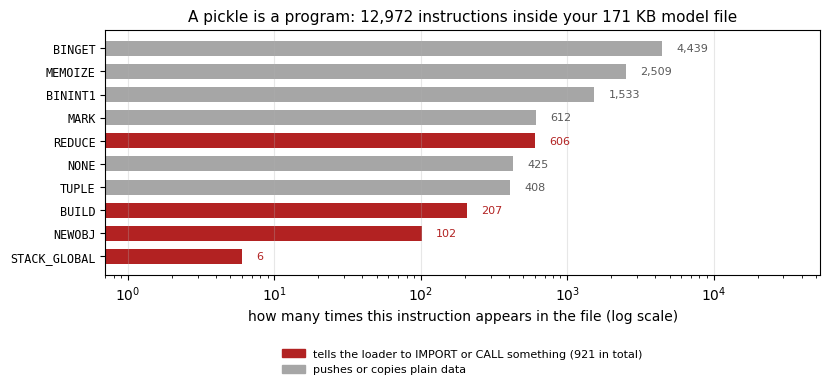

pickle opcodes in the file        : 12,972
of which import / construct / call: 921

What `pickle.load` on this file is instructed to import, in order:
  sklearn.ensemble._forest.RandomForestClassifier
  sklearn.tree._classes.DecisionTreeClassifier
  numpy._core.numeric._frombuffer
  numpy.dtype
  numpy._core.multiarray.scalar
  sklearn.tree._tree.Tree


In [3]:
# WHAT: disassemble the pickle file WITHOUT loading it, count its opcodes, and list
# every module.callable the opcode stream tells the loader to import.
# WHY: pickletools.genops reads the byte stream as instructions instead of executing
# them - exactly what a model-hub scanner does. It is the only way to inspect a
# pickle safely, because pickle.load() would already have run the file by the time
# you could look at the object it returned.
import collections
import io
import pickletools

from matplotlib.patches import Patch
import matplotlib.pyplot as plt

raw = open(PICKLE_PATH, "rb").read()

# Opcodes that make the loader import, construct or call something. Everything
# else only pushes bytes around. GLOBAL/STACK_GLOBAL is the import; REDUCE is the call.
EXECUTING = {"GLOBAL", "STACK_GLOBAL", "REDUCE", "INST", "OBJ",
             "NEWOBJ", "NEWOBJ_EX", "BUILD"}

counts = collections.Counter()
recent_strings, imports = [], []
for opcode, arg, _pos in pickletools.genops(io.BytesIO(raw)):   # never executes
    counts[opcode.name] += 1
    if opcode.name in ("SHORT_BINUNICODE", "BINUNICODE", "UNICODE"):
        recent_strings.append(arg)                              # module / name literals
    elif opcode.name == "STACK_GLOBAL" and len(recent_strings) >= 2:
        imports.append((recent_strings[-2], recent_strings[-1]))
    elif opcode.name == "GLOBAL":
        imports.append(tuple(arg.split()))

total_ops = sum(counts.values())
exec_ops = sum(v for k, v in counts.items() if k in EXECUTING)

# Plot every executing opcode present, plus the six commonest data opcodes,
# so the rare-but-decisive ones (6 imports) stay visible next to the common ones.
exec_present = [(k, v) for k, v in counts.most_common() if k in EXECUTING]
data_present = [(k, v) for k, v in counts.most_common() if k not in EXECUTING][:6]
top = sorted(exec_present + data_present, key=lambda kv: kv[1])
names = [k for k, _ in top]
vals = [v for _, v in top]
colors = ["firebrick" if k in EXECUTING else "0.65" for k in names]

fig, ax = plt.subplots(figsize=(8.4, 4.2))
y = np.arange(len(names))
ax.barh(y, vals, color=colors, height=0.65)
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=8.5, family="monospace")
ax.set_xscale("log")                       # 6 and 4,439 have to share one axis
ax.set_xlim(0.7, max(vals) * 12)
ax.set_xlabel("how many times this instruction appears in the file (log scale)")
ax.set_title(f"A pickle is a program: {total_ops:,} instructions inside your "
             f"{len(raw)/1024:.0f} KB model file", fontsize=11)
for yi, (v, k) in enumerate(zip(vals, names)):
    ax.text(v * 1.25, yi, f"{v:,}", va="center", fontsize=8,
            color="firebrick" if k in EXECUTING else "0.35")
ax.legend(handles=[Patch(color="firebrick",
                         label=f"tells the loader to IMPORT or CALL something ({exec_ops:,} in total)"),
                   Patch(color="0.65", label="pushes or copies plain data")],
          loc="upper center", bbox_to_anchor=(0.5, -0.26), ncol=1, fontsize=8, frameon=False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"pickle opcodes in the file        : {total_ops:,}")
print(f"of which import / construct / call: {exec_ops:,}")
print("\nWhat `pickle.load` on this file is instructed to import, in order:")
seen = []
for module, name in imports:
    if (module, name) not in seen:
        seen.append((module, name))
        print(f"  {module}.{name}")

**Read the figure.** The x-axis is a log scale because the interesting instructions are the *rare* ones. Grey bars are bookkeeping: `BINGET` copies a value it already read, `BININT1` pushes a small integer, `MEMOIZE` remembers one. They move bytes and nothing else.

The red bars are the ones that matter, and there are four of them:

- **`STACK_GLOBAL` — 6.** Six imports. The list printed under the figure names them: `RandomForestClassifier`, `DecisionTreeClassifier`, `numpy.dtype`, and three more. `pickle.load` performs those imports **before** it hands you anything you could inspect.
- **`NEWOBJ` (102), `BUILD` (207), `REDUCE` (606).** Construct an object; fill in its state; *call* something with arguments. Nine hundred-odd instructions in one 171 KB file whose job is to call things.

Every name on that printed list is harmless — it is your own scikit-learn forest. That is precisely the problem: **the format has no way to distinguish this list from one containing `os.system` or `builtins.exec`.** The opcode is identical; only the string next to it differs. A file arriving from a colleague, a Kaggle kernel or a model hub is a program you are about to run, and this disassembly is the only look you get before running it.

Two practical consequences, both of which show up again in "⚠️ Where this breaks":

1. `pickletools.genops` is a safe first move on any artifact you did not create. It is what a hub scanner does.
2. The ONNX file written in section 5 has no equivalent of these red bars — it is a protobuf graph of operators a runtime interprets, not a list of Python callables to import. That, and not the file size, is the strongest argument for ONNX when the artifact crosses an organisational boundary.

## 4  joblib

joblib is the format recommended by scikit-learn. It uses memory mapping for large arrays, offers optional compression, and is faster than pickle for numpy-heavy objects **once those arrays are big enough for memory mapping to pay for itself** — the measurement in section 6 shows this 180 KB forest is nowhere near that size. Same Python-version caveat applies, but it handles large model files better.


In [4]:
# WHAT: save the same model with joblib, with and without compression.
# WHY: joblib stores NumPy arrays efficiently, which is why scikit-learn recommends it
# over pickle for models full of large arrays — and compression shrinks the file further.
import joblib
import os

JOBLIB_PATH = "/tmp/iris_rf.joblib"
JOBLIB_COMPRESSED = "/tmp/iris_rf_compressed.joblib"

# Save uncompressed
joblib.dump(clf, JOBLIB_PATH)

# Save with compression level 3 (good balance of speed vs size)
joblib.dump(clf, JOBLIB_COMPRESSED, compress=3)

# Load and verify
# Round-trip check again: load the artifact and confirm predictions match.
clf_jbl = joblib.load(JOBLIB_PATH)
jbl_preds = clf_jbl.predict(X_test)
match = np.array_equal(jbl_preds, reference_preds)
print(f"Joblib predictions match original: {match}")
print(f"Joblib uncompressed : {os.path.getsize(JOBLIB_PATH) / 1024:.1f} KB")
print(f"Joblib compressed   : {os.path.getsize(JOBLIB_COMPRESSED) / 1024:.1f} KB")

Joblib predictions match original: True
Joblib uncompressed : 182.5 KB
Joblib compressed   : 25.4 KB


## 5  ONNX — Open Neural Network Exchange

ONNX is an open format that describes a model as a computation graph independent of any ML framework. Once converted, the model can run on any runtime that supports ONNX — including mobile devices, browsers, and C++ services — without Python. The `skl2onnx` library converts sklearn models; `onnxruntime` runs them.


In [5]:
# Install ONNX dependencies if not already present
import subprocess, sys
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "skl2onnx", "onnxruntime"],
    capture_output=True, text=True
)
print(result.stdout[-200:] if result.stdout else "Already installed")


Already installed


In [6]:
# WHAT: convert the model to ONNX and run it with onnxruntime instead of sklearn.
# WHY: ONNX is a framework-neutral format — the serving machine no longer needs
# scikit-learn installed, which is the whole point for production and edge targets.
ONNX_PATH = "/tmp/iris_rf.onnx"

try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    import onnxruntime as rt
    import os

    # Step 1: Convert to ONNX
    # FloatTensorType([None, 4]) means variable batch size, 4 features
    initial_type = [("float_input", FloatTensorType([None, 4]))]
    onnx_model = convert_sklearn(clf, initial_types=initial_type)

    with open(ONNX_PATH, "wb") as f:
        f.write(onnx_model.SerializeToString())

    print(f"ONNX file size: {os.path.getsize(ONNX_PATH) / 1024:.1f} KB")

    # Step 2: Run inference with onnxruntime (no sklearn needed)
    sess = rt.InferenceSession(ONNX_PATH)
    input_name = sess.get_inputs()[0].name
    label_name = sess.get_outputs()[0].name

    onnx_preds = sess.run([label_name], {input_name: X_test})[0]
    match = np.array_equal(onnx_preds, reference_preds)
    print(f"ONNX predictions match original: {match}")
    print(f"First 10 ONNX predictions: {onnx_preds[:10]}")

# Graceful fallback: if the converter is missing, show the recipe instead of crashing.
except ImportError:
    print("skl2onnx or onnxruntime not available in this environment.")
    print("ONNX conversion pattern (what the code above does):")
    print("  1. from skl2onnx import convert_sklearn")
    print("  2. onnx_model = convert_sklearn(clf, initial_types=[('float_input', FloatTensorType([None, 4]))])")
    print("  3. Save with open('model.onnx', 'wb').write(onnx_model.SerializeToString())")
    print("  4. Load with onnxruntime.InferenceSession('model.onnx')")
    print("  5. Run with sess.run([output_name], {input_name: X_test})")

ONNX file size: 78.3 KB
ONNX predictions match original: True
First 10 ONNX predictions: [1 0 2 1 1 0 1 2 1 1]


## 6  Format comparison

| Format | Python-only? | File size | Best for |
|--------|-------------|-----------|----------|
| pickle | Yes (same version) | Medium | Quick experiments, internal tools |
| joblib | Yes (same version) | Small–medium (with compression) | sklearn models in Python services |
| ONNX   | No — any ONNX runtime | Small | Cross-language, mobile, edge, high-performance inference |

**Rule of thumb:** use joblib inside a Python microservice; use ONNX when you need to cross a language boundary or deploy to a device that cannot run Python.


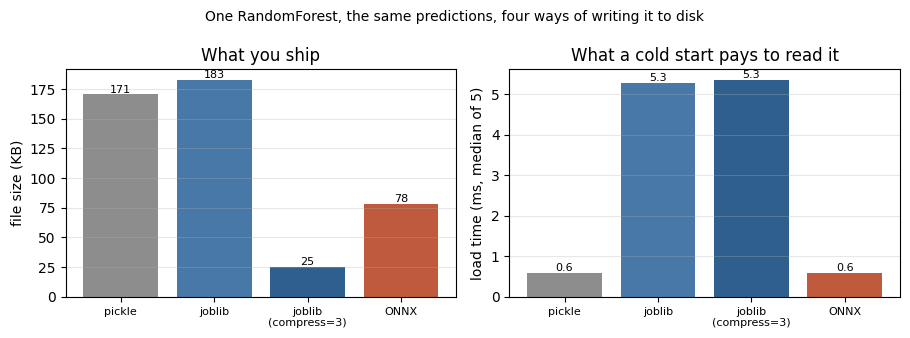

format                  size (KB)  load (ms)
pickle                      170.6       0.59
joblib                      182.5       5.28
joblib (compress=3)          25.4       5.35
ONNX                         78.3       0.59


In [7]:
# WHAT: put the table above on one axis - measure the size of each file we just
# wrote, and how long each one takes to load back into a usable model.
# WHY: "small", "medium" and "slower" are words; a deployment decision needs the
# numbers for YOUR artifact. Both panels use the four files created earlier in
# this notebook - nothing here is re-trained or estimated.
import os
import time

import matplotlib.pyplot as plt

def median_load_ms(load_fn, reps=5):
    """Median wall-clock time of loading an artifact (first call discarded)."""
    load_fn()                                   # warm the OS file cache
    times = []
    for _ in range(reps):
        t0 = time.perf_counter()
        load_fn()
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.median(times))

candidates = [
    ("pickle", PICKLE_PATH, lambda: pickle.load(open(PICKLE_PATH, "rb"))),
    ("joblib", JOBLIB_PATH, lambda: joblib.load(JOBLIB_PATH)),
    ("joblib\n(compress=3)", JOBLIB_COMPRESSED, lambda: joblib.load(JOBLIB_COMPRESSED)),
]
# ONNX only if the conversion cell above actually produced a file.
if os.path.exists(ONNX_PATH):
    import onnxruntime as rt
    candidates.append(
        ("ONNX", ONNX_PATH,
         lambda: rt.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"]))
    )

names = [c[0] for c in candidates]
sizes_kb = [os.path.getsize(c[1]) / 1024 for c in candidates]
load_ms = [median_load_ms(c[2]) for c in candidates]

colors = ["#8d8d8d", "#4878a8", "#2f5f8f", "#c05a3c"][:len(candidates)]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
axes[0].bar(names, sizes_kb, color=colors)
axes[0].set_ylabel("file size (KB)")
axes[0].set_title("What you ship")
for i, v in enumerate(sizes_kb):
    axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
axes[1].bar(names, load_ms, color=colors)
axes[1].set_ylabel("load time (ms, median of 5)")
axes[1].set_title("What a cold start pays to read it")
for i, v in enumerate(load_ms):
    axes[1].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
for a in axes:
    a.tick_params(axis="x", labelsize=8)
    a.grid(axis="y", alpha=0.3)
fig.suptitle("One RandomForest, the same predictions, four ways of writing it to disk", fontsize=10)
plt.tight_layout()
plt.show()

print(f"{'format':22} {'size (KB)':>10} {'load (ms)':>10}")
for n, s, ms in zip(names, sizes_kb, load_ms):
    print(f"{n.replace(chr(10), ' '):22} {s:10.1f} {ms:10.2f}")

**Read the figure.** The left panel is the table above, drawn: `compress=3` shrinks the artifact by roughly 7x, ONNX by roughly 2x against pickle, and pickle and plain joblib come out at practically the same size.

The right panel is the one worth arguing about, because it does **not** show what the prose above would lead you to expect.

- **Compression is free here.** The compressed file is roughly seven times smaller and loads in the same time as the uncompressed one to within run-to-run noise — re-run the cell and which of those two bars is taller changes. Inflating 25 KB costs less than the fixed overhead of the load call itself. Discussion question 3 asks what that trade does to a pod cold start; at *this* artifact size there is no measurable cost to trade away. The two bars separate only for a model whose arrays are hundreds of megabytes, not hundreds of kilobytes.
- **joblib is not faster than pickle at this scale.** For a 180 KB forest, joblib's array-aware machinery is pure overhead, and the bar shows it. Its advantage is memory-mapping large arrays — arrays this dataset never produces. Read this as the "⚠️ Where this breaks" section warns: these ratios belong to *this* artifact, and the honest move for your own model is to re-run this cell on it rather than inherit a rule of thumb.

Both panels measure the *same* saved model, and every format reproduced the reference predictions exactly. Size and load time are therefore the only axes on which you are choosing.

## 💬 Discuss

Read the three measured results together — pickle 170.6 KB, joblib 182.5 KB (25.4 KB compressed), ONNX 78.3 KB, and **all three reproducing the reference predictions exactly**. The numbers settle the size question. They do not settle these.

1. All three round-tripped perfectly here. Does that make them equally trustworthy? Name one thing that could have gone wrong on load that `np.array_equal(loaded_preds, reference_preds)` would still have reported as `True`.
2. Your team ships a model to a partner bank that will run it inside their own network, in Java. Compare the ONNX path against the alternative of exposing an HTTP API they call across the boundary. Which one would *you* argue for, and what does the bank's security team say about each?
3. joblib's compressed file is 7× smaller than the uncompressed one but costs CPU time on every load. In a Kubernetes deployment that scales from 2 pods to 10 during a traffic spike, does that trade help you or hurt you? Sketch the timeline of a cold start before you answer.

## Summary

Serialization converts a live model object into bytes on disk. pickle and joblib are Python-specific and easiest to use but tie you to a specific Python/sklearn version. ONNX breaks that dependency by representing the model as a framework-independent graph, enabling deployment to mobile, edge, and non-Python services. Always verify after loading: run `predict()` on a known sample and check that the output matches the original.


## Self-check

1. **What breaks if you pickle a sklearn model and load it in a newer Python version?** Think about what pickle stores alongside the model weights.
2. **Why is ONNX preferred for mobile or edge devices?** Consider that iOS and Android apps cannot run a full Python interpreter.
3. **How do you verify a model loaded correctly after deserialization?** Look at the code cells where we checked `np.array_equal(loaded_preds, reference_preds)` — what would a mismatch tell you?


## ⚠️ Where this breaks

- **pickle and joblib are not a distribution format.** They are a Python-to-Python convenience. Loading one executes code, so "download a `.pkl` from a colleague, a Kaggle kernel or a model hub and load it" is running an unverified program — the exact risk Hugging Face's pickle-import scan exists to surface. For anything you did not produce yourself, prefer ONNX (a data-only graph) or a scanned/`safetensors`-style format.
- **The version coupling is real and silent.** A joblib file records the classes it needs by name. Load it under a different scikit-learn version and you may get a working object with subtly different internals, not a clean error. Pin `scikit-learn==` in the same commit as the artifact (Unit 5, notebook 06 turns this into an audit record).
- **ONNX is not a universal escape hatch.** `skl2onnx` covers the common estimators; custom transformers, arbitrary Python in a `FunctionTransformer`, and anything with non-standard `predict` logic either fail to convert or convert into something that quietly disagrees with sklearn at the edges. The rule that survives contact with production: **convert, then re-run your held-out set through the ONNX session and compare predictions**, exactly as the cell above did — never assume the conversion was faithful.
- **What this comparison cannot tell you.** Everything here is a 170 KB RandomForest on 4 features. File-size ratios and load times at that scale do not extrapolate; joblib's memory-mapping advantage only appears when the arrays are large enough to matter, which is precisely the case this dataset cannot show you.
- **The cheaper alternative.** If the model, the trainer and the server are all the same Python environment inside one container image you built and pinned, `joblib` is the correct boring choice and ONNX is added complexity buying you portability you are not using.

## 📚 References

1. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
2. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
3. Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). *Challenges in Deploying Machine Learning: A Survey of Case Studies*. ACM Computing Surveys. <https://arxiv.org/abs/2011.09926>
